# Livrable 1 : classification du type d'image avec un réseau de neurones

Groupe :
* Isrâ BOUDEMAGH
* Théophile NOEL
* Bruno RIECKENBERG
* Corentin ROMANO

## Objectif

Ce notebook entraîne un **réseau de neurones convolutif (CNN)** avec TensorFlow / Keras pour reconnaître le **type d'une image**. Dans cette première version le jeu de données a deux dossiers : **`Photo`** et **`Others`** (tout le reste : peintures, dessins, schémas, captures…).

**Modèle retenu : `lucky_model2.keras`** (2 classes, 94,3 % d'accuracy sur le test). C'est le meilleur modèle de ce notebook et c'est lui qui est testable sur le site (`Test_website`, modèle `model_photo_autre`). Le code d'entraînement laissé dans le notebook sert de comparaison.

La version suivante (`L1,1.ipynb`) sépare les peintures dans une classe à part (`Others` / `Painting` / `Photo`).

## Plan du notebook

| Partie | Contenu |
|---|---|
| 1 | Données : nettoyage, découpage entraînement / test, augmentation |
| 2 | **Code TensorFlow + schéma de l'architecture**, paramètres du réseau |
| 3 | **Fonction de perte** |
| 4 | **Algorithme d'optimisation (Adam)** et callbacks |
| 5 | **Courbes** d'erreur et d'accuracy (entraînement et test) |
| 6 | **Analyse des résultats : biais / variance** (sous- et sur-apprentissage) |
| 7 | **Méthodes pour améliorer le compromis biais / variance** |

> Vocabulaire : dans le code, le jeu de **test** (`test_set`) est le sous-ensemble *validation* de Keras (20 % des
> images). Il n'est jamais utilisé pour mettre à jour les poids, mais il sert à choisir l'époque d'arrêt
> (voir partie 6, limites).

In [2]:
# Bibliothèques : TensorFlow / Keras pour le réseau, NumPy pour les calculs, Matplotlib pour les graphiques
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
import pathlib
import shutil

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Vérification de l'environnement : l'entraînement est fait sur GPU (CUDA), environ 50 s par époque
print(tf.__version__)
print("Compilé avec CUDA :", tf.test.is_built_with_cuda())
print("GPU détectés :", tf.config.list_physical_devices('GPU'))

I0000 00:00:1790923689.287050   58726 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790923689.748901   58726 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790923691.809440   58726 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0
Compilé avec CUDA : True
GPU détectés : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790923694.126678   58726 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Les données

Le dossier `dataset/` contient un sous-dossier par classe ; Keras déduit les étiquettes du nom des dossiers,
**dans l'ordre alphabétique** (`Others`, `Photo`). C'est cet ordre qui donne l'indice de chaque sortie du réseau.

Étapes :
1. **Nettoyage** : certaines images téléchargées sont corrompues ou ne sont pas de vrais JPEG/PNG. TensorFlow
   s'arrêterait en plein entraînement en les rencontrant, on les répare (ré-encodage) ou on les écarte avant.
2. **Découpage 80 % / 20 %** : 80 % des images pour l'entraînement, 20 % pour le test.
3. **Augmentation de données** (dans le modèle) pour limiter le sur-apprentissage.

In [6]:
# Un sous-dossier par classe : Keras utilisera le nom des dossiers comme étiquette (ordre alphabétique)
dataset_path = pathlib.Path("./dataset")
print([p.name for p in dataset_path.iterdir()])

['Others', 'Photo']


In [7]:
from PIL import Image
import shutil

def nettoyer_dataset(root, dossier_rejets):
    """Vérifie que chaque fichier est une image que TensorFlow sait décoder.

    Une seule image illisible suffit à faire planter l'entraînement au milieu d'une époque :
    - si TensorFlow ne sait pas la lire mais Pillow oui (format exotique, faux .jpg…), on la ré-encode en JPEG ;
    - si personne ne sait la lire, on la déplace dans dossier_rejets (rien n'est supprimé).
    """
    root, dossier_rejets = pathlib.Path(root), pathlib.Path(dossier_rejets)
    reparees, rejetees = [], []
    for p in sorted(root.rglob("*")):
        if not p.is_file():
            continue
        try:
            # même décodeur que celui utilisé par image_dataset_from_directory
            tf.io.decode_image(tf.io.read_file(str(p)), channels=3, expand_animations=False)
        except tf.errors.InvalidArgumentError:
            try:
                with Image.open(p) as im:
                    im = im.convert("RGB")
                im.save(p, "JPEG", quality=95)   # ré-encodage en vrai JPEG
                reparees.append(p)
            except Exception:
                cible = dossier_rejets / p.relative_to(root)
                cible.parent.mkdir(parents=True, exist_ok=True)
                shutil.move(str(p), str(cible))  # image illisible : on la sort du dataset
                rejetees.append(p)
    print(f"{len(reparees)} réparée(s), {len(rejetees)} rejetée(s)")
    return reparees, rejetees

nettoyer_dataset(dataset_path, "./Livrable1_rejets")

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1790923850.227216   58726 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


0 réparée(s), 0 rejetée(s)


([], [])

### Paramètres d'entrée

| Paramètre | Valeur | Pourquoi |
|---|---|---|
| Taille des images | 200 × 200 | Assez grand pour garder les indices utiles (grain de la photo, coups de pinceau, aplats de couleur), assez petit pour tenir en mémoire GPU avec 40 000 images. Les images sont redimensionnées (interpolation bilinéaire) par `image_dataset_from_directory`. |
| Taille de batch | 128 | Bon débit sur GPU et gradient moins bruité qu'avec de petits batchs ; 33 120 images ÷ 128 = 259 pas par époque. |
| `validation_split` | 0,2 | 20 % des images pour mesurer l'erreur de test. |
| `seed` | 42 | Même graine pour les deux appels : les deux sous-ensembles sont complémentaires, aucune image n'est à la fois en entraînement et en test, et le découpage est reproductible. |

In [9]:
# Paramètres d'entrée (justifiés dans le tableau au-dessus)
image_h = 200    # hauteur des images données au réseau (pixels)
image_w = 200    # largeur
batch_s = 128    # nombre d'images traitées avant chaque mise à jour des poids

In [10]:
# Découpage 80 % entraînement / 20 % test.
# Les deux appels utilisent la même graine (seed=42) : Keras mélange la liste des fichiers de la même façon,
# donc 'training' et 'validation' sont complémentaires (aucune image dans les deux) et reproductibles.
# Les images sont redimensionnées en image_h x image_w (bilinéaire) et regroupées en batchs ;
# les étiquettes sont des entiers 0, 1, 2… dans l'ordre alphabétique des dossiers.

# Le train_set
train_set = tf.keras.preprocessing.image_dataset_from_directory(
  dataset_path,
  validation_split=  0.2,
  subset =  'training',
  seed=42,
  image_size = (image_h, image_w),
  batch_size = batch_s
)
# Le test_set (sous-ensemble « validation » de Keras : jamais utilisé pour mettre à jour les poids)
test_set = tf.keras.preprocessing.image_dataset_from_directory(
  dataset_path,
  validation_split= 0.2,
  subset = 'validation',
  seed= 42,
  image_size = (image_h, image_w),
  batch_size = batch_s
)

Found 41399 files belonging to 2 classes.
Using 33120 files for training.
Found 41399 files belonging to 2 classes.
Using 8279 files for validation.


In [11]:
# Ordre des classes = ordre des sorties du réseau (indice 0, 1, 2…)
class_names = train_set.class_names
print(class_names)

['Others', 'Photo']


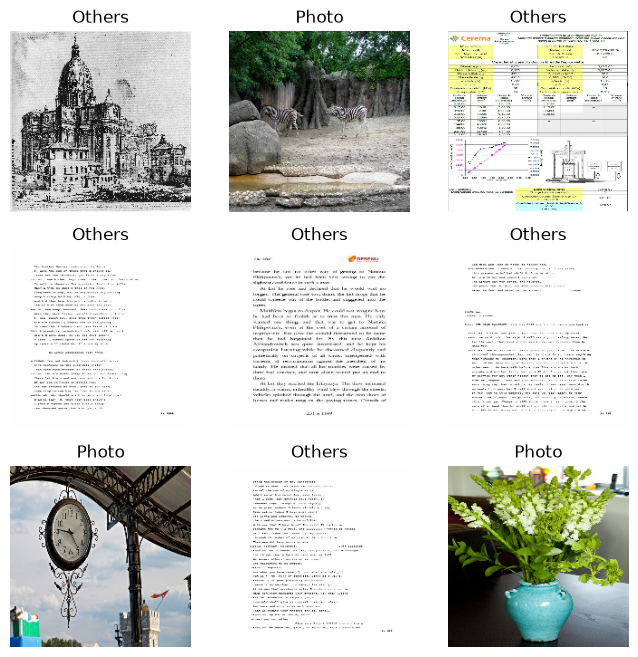

In [12]:
import matplotlib.pyplot as plt

# Aperçu de 9 images du premier batch d'entraînement avec leur étiquette, pour vérifier les données
plt.figure(figsize=(8, 8))
for images, labels in train_set.take(1):
    for i in range(9):
        ax = plt.subplot(3,3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [13]:
# Forme d'un batch : (taille du batch, hauteur, largeur, 3 canaux RGB) et une étiquette entière par image
print(type(train_set))
images, labels =  next(iter(train_set))
print(images.shape)
print(labels.shape)

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
(128, 200, 200, 3)
(128,)


In [9]:
# Optimisation du pipeline de données, désactivée volontairement :
# .cache() garderait toutes les images décodées en mémoire, soit 33 120 x 200 x 200 x 3 valeurs float32
# ≈ 16 Go pour l'entraînement seul : plus que la RAM disponible. Les images sont donc relues sur disque à
# chaque époque (plus lent, mais ça tient). .prefetch() seul serait possible sans risque mémoire.

# AUTOTUNE = tf.data.experimental.AUTOTUNE

# train_set = train_set.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
# test_set = test_set.cache().prefetch(buffer_size=AUTOTUNE)

### Augmentation de données

Ces couches modifient **aléatoirement** chaque image *à chaque époque* (elles ne sont actives que pendant
l'entraînement ; à la prédiction elles ne font rien). Le réseau ne voit donc jamais deux fois exactement la même
image, ce qui l'empêche d'apprendre les images par cœur : c'est une **régularisation** qui réduit la variance.

| Couche | Effet |
|---|---|
| `RandomFlip("horizontal")` | miroir gauche-droite (une photo retournée reste une photo) |
| `RandomRotation(0.1)` | rotation aléatoire de ± 10 % d'un tour, soit ± 36° |
| `RandomZoom(0.2)` | zoom avant ou arrière de ± 20 % |

On n'a **pas** ajouté de modification des couleurs (contraste, luminosité) : la palette de couleurs est justement
un indice important pour distinguer une peinture d'une photo.

In [14]:
# Augmentation de données : transformations aléatoires appliquées seulement pendant l'entraînement
# (désactivées à la prédiction). C'est une régularisation : le réseau voit des variantes différentes
# de chaque image à chaque époque et apprend moins par cœur.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(image_h, image_w, 3)),  # miroir gauche-droite
    layers.RandomRotation(0.1),   # rotation de ± 0,1 tour = ± 36°
    layers.RandomZoom(0.2),       # zoom de ± 20 %
])

/home/theophile/envs/tf-gpu/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 2. Le réseau de neurones : code TensorFlow et architecture

### Schéma de l'architecture

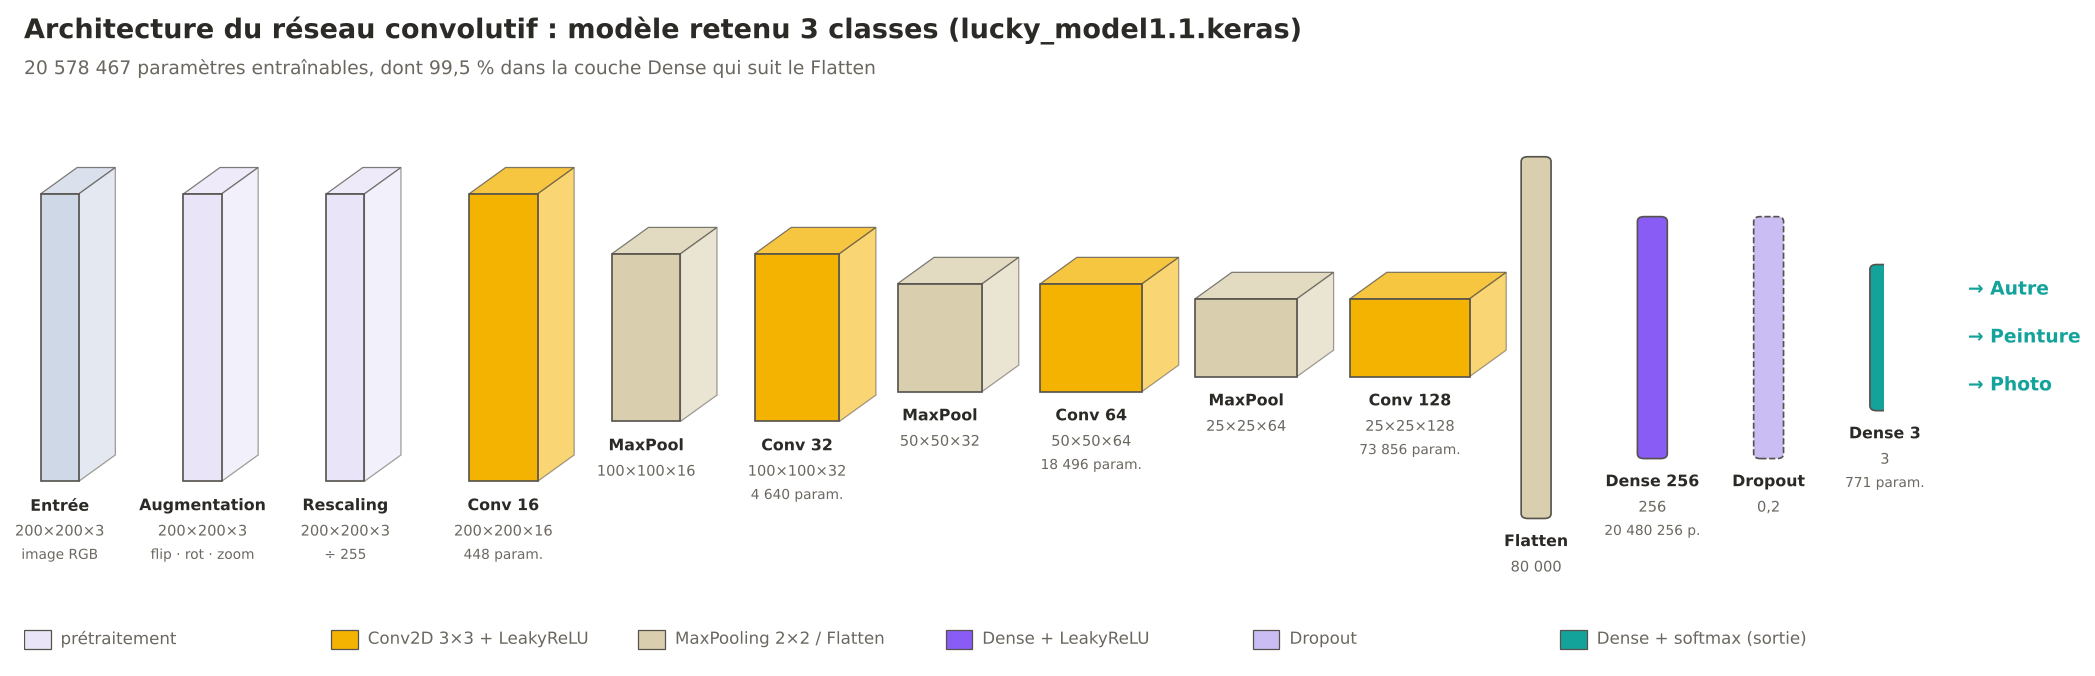

Le réseau est un **CNN séquentiel** (`keras.Sequential`) : une partie **convolutive** qui extrait des
caractéristiques visuelles (contours, textures, motifs), puis une partie **dense** qui les combine pour décider de la classe.

### Paramètres du réseau, couche par couche

| # | Couche | Taille de sortie | Paramètres | Détail du calcul |
|---|---|---|---|---|
| 0 | Augmentation (flip, rotation, zoom) | 200×200×3 | 0 | |
| 1 | `Rescaling(1/255)` | 200×200×3 | 0 | pixels ramenés de [0, 255] à [0, 1] |
| 2 | `Conv2D(16, 3×3, same)` + LeakyReLU | 200×200×16 | 448 | 3·3·3·16 + 16 biais |
| 3 | `MaxPooling2D(2×2)` | 100×100×16 | 0 | |
| 4 | `Conv2D(32, 3×3, same)` + LeakyReLU | 100×100×32 | 4 640 | 3·3·16·32 + 32 |
| 5 | `MaxPooling2D(2×2)` | 50×50×32 | 0 | |
| 6 | `Conv2D(64, 3×3, same)` + LeakyReLU | 50×50×64 | 18 496 | 3·3·32·64 + 64 |
| 7 | `MaxPooling2D(2×2)` | 25×25×64 | 0 | |
| 8 | `Conv2D(128, 3×3, same)` + LeakyReLU | 25×25×128 | 73 856 | 3·3·64·128 + 128 |
| 9 | `Flatten` | 80 000 | 0 | 25·25·128 |
| 10 | `Dense(256)` + LeakyReLU | 256 | **20 480 256** | 80 000·256 + 256 |
| 11 | `Dropout(0.2)` | 256 | 0 | |
| 12 | `Dense(3)` + softmax | 3 | 771 | 256·3 + 3 |
| | **Total** | | **20 578 467** | |

### Pourquoi ces choix

* **Convolutions 3×3 avec `padding='same'`** : petits filtres empilés (idée de VGG) ; deux convolutions 3×3
  successives voient autant qu'une 5×5 avec moins de paramètres. `same` ajoute une bordure de zéros pour garder la
  taille de l'image et ne pas perdre les bords.
* **Nombre de filtres 16 → 32 → 64 → 128** : chaque `MaxPooling` divise la résolution par 2, on double le nombre de
  filtres pour garder une quantité d'information comparable : les premières couches détectent des motifs simples
  (contours, grain), les suivantes des motifs plus abstraits (textures de pinceau, objets).
* **LeakyReLU** (pente négative 0,2 par défaut dans Keras 3) plutôt que ReLU : un neurone qui reçoit une entrée
  négative garde un petit gradient, ce qui évite les neurones « morts » qui ne s'entraînent plus.
* **MaxPooling 2×2** : réduit le calcul et rend le réseau un peu insensible aux petits décalages.
* **Flatten + Dense(256)** : met toutes les caractéristiques à plat et les combine. C'est simple mais très coûteux :
  cette couche contient **99,5 % des paramètres** du réseau (voir l'analyse, c'est le principal levier contre le
  sur-apprentissage).
* **Dropout(0.2)** : pendant l'entraînement, 20 % des 256 neurones sont éteints au hasard à chaque pas, ce qui
  empêche le réseau de dépendre de quelques neurones précis (régularisation).
* **Sortie `Dense(3, softmax)`** : une sortie par classe (`Others`, `Painting`, `Photo`, ce code a été écrit pour le jeu à 3 classes ; avec les 2 dossiers de ce notebook, la 3ᵉ sortie ne correspond à aucune image et le réseau apprend à lui donner une probabilité ≈ 0. Pour un vrai modèle 2 classes on écrirait `Dense(len(class_names))`) ; le softmax transforme les scores en
  probabilités positives dont la somme vaut 1 ; la classe prédite est celle de plus forte probabilité.

## 3. La fonction de perte : entropie croisée catégorielle

On utilise `SparseCategoricalCrossentropy`. Pour une image d'étiquette $y$ et des probabilités prédites
$p_1, \dots, p_K$ (sorties du softmax), la perte est :

$$\mathcal{L} = -\log p_{y}$$

et on minimise sa moyenne sur le batch : $\; \mathcal{L}_{\text{batch}} = -\frac{1}{N}\sum_{i=1}^{N} \log p_{i,\,y_i}$.

* Si le réseau donne une probabilité de 1 à la bonne classe, la perte vaut 0 ; s'il est sûr de lui et se trompe,
  la perte devient très grande. Elle punit donc fortement les erreurs commises avec assurance, et donne un
  gradient fort même quand le réseau se trompe beaucoup (contrairement à l'erreur quadratique combinée au softmax).
* C'est la **vraisemblance** du modèle : minimiser l'entropie croisée revient à maximiser la probabilité des
  bonnes étiquettes. C'est la perte standard de la classification multi-classes.
* **« Sparse »** car les étiquettes sont des entiers (0, 1, 2…) comme les fournit `image_dataset_from_directory`, et
  non des vecteurs *one-hot*.
* C'est cette perte que les courbes appellent **« erreur »** (loss) d'entraînement et de test.

> Remarque sur `from_logits=True` : la dernière couche a déjà un softmax, donc ses sorties sont des probabilités
> et non des *logits*. Keras le détecte (avertissement `received from_logits=True, but the output argument was
> produced by a Softmax activation` dans les logs) et calcule la perte à partir des valeurs juste avant le
> softmax : le résultat est correct. L'écriture cohérente serait `from_logits=False` (ou garder `from_logits=True`
> et retirer le softmax de la dernière couche).

## 4. L'algorithme d'optimisation : Adam

L'entraînement est une **descente de gradient** : à chaque batch, TensorFlow calcule le gradient
$g_t = \nabla_\theta \mathcal{L}$ de la perte par rétropropagation, puis l'optimiseur met les poids $\theta$ à jour.
Nous utilisons **Adam** (*Adaptive Moment Estimation*) :

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\,g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)\,g_t^2$$
$$\hat m_t = \frac{m_t}{1-\beta_1^t} \qquad \hat v_t = \frac{v_t}{1-\beta_2^t} \qquad \theta_t = \theta_{t-1} - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}$$

* $m_t$ est une moyenne glissante du gradient (**momentum** : on garde l'élan, on traverse les zones plates et on
  amortit les oscillations) ;
* $v_t$ est une moyenne glissante du carré du gradient : chaque poids a **son propre pas**, plus petit si son
  gradient est grand ou bruité, plus grand sinon ;
* hyperparamètres : taux d'apprentissage $\eta = 10^{-3}$ (`learning_rate`), et valeurs par défaut de Keras
  $\beta_1 = 0{,}9$, $\beta_2 = 0{,}999$, $\varepsilon = 10^{-7}$.

**Pourquoi Adam** plutôt qu'une descente de gradient stochastique (SGD) simple : il converge vite et marche bien
sans réglage fin du pas, ce qui convient à un premier modèle. Adam stocke $m$ et $v$ pour chaque poids : c'est pour
cela que le modèle sauvegardé indique « Optimizer params » ≈ 2 × les paramètres entraînables (et que le fichier
`.keras` pèse environ 235 Mo).

### Les callbacks : quand baisser le pas, quand s'arrêter

| Callback | Réglage | Rôle |
|---|---|---|
| `ReduceLROnPlateau` | surveille `val_loss`, `factor=0.75`, `patience=epochs//100` = 1, `min_lr=1e-5` | Dès que la perte de test ne s'améliore pas pendant une époque, le pas est multiplié par 0,75. Un grand pas au début pour avancer vite, puis des pas de plus en plus fins pour se poser au fond du minimum. |
| `EarlyStopping` | surveille `val_loss`, `patience=epochs//10` = 15, `restore_best_weights=True` | Arrête l'entraînement si la perte de test ne s'améliore plus pendant 15 époques et **remet les poids de la meilleure époque** : c'est un garde-fou contre le sur-apprentissage. |
| `epochs` | 150 | Maximum jamais atteint : c'est l'early stopping qui décide de la fin. |

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,578,467 (78.50 MB)

 Trainable params: 20,578,467 (78.50 MB)

 Non-trainable params: 0 (0.00 B)

...

259/259 ━━━━━━━━━━━━━━━━━━━━ 50s 191ms/step - accuracy: 0.9531 - loss: 0.1297 - val_accuracy: 0.9209 - val_loss: 0.2237 - learning_rate: 1.0000e-05
Epoch 35/150
126/259 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.9527 - loss: 0.1286

W0000 00:00:1790774076.523470   21747 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9528 - loss: 0.1274

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


259/259 ━━━━━━━━━━━━━━━━━━━━ 50s 191ms/step - accuracy: 0.9528 - loss: 0.1274 - val_accuracy: 0.9194 - val_loss: 0.2289 - learning_rate: 1.0000e-05
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 20.


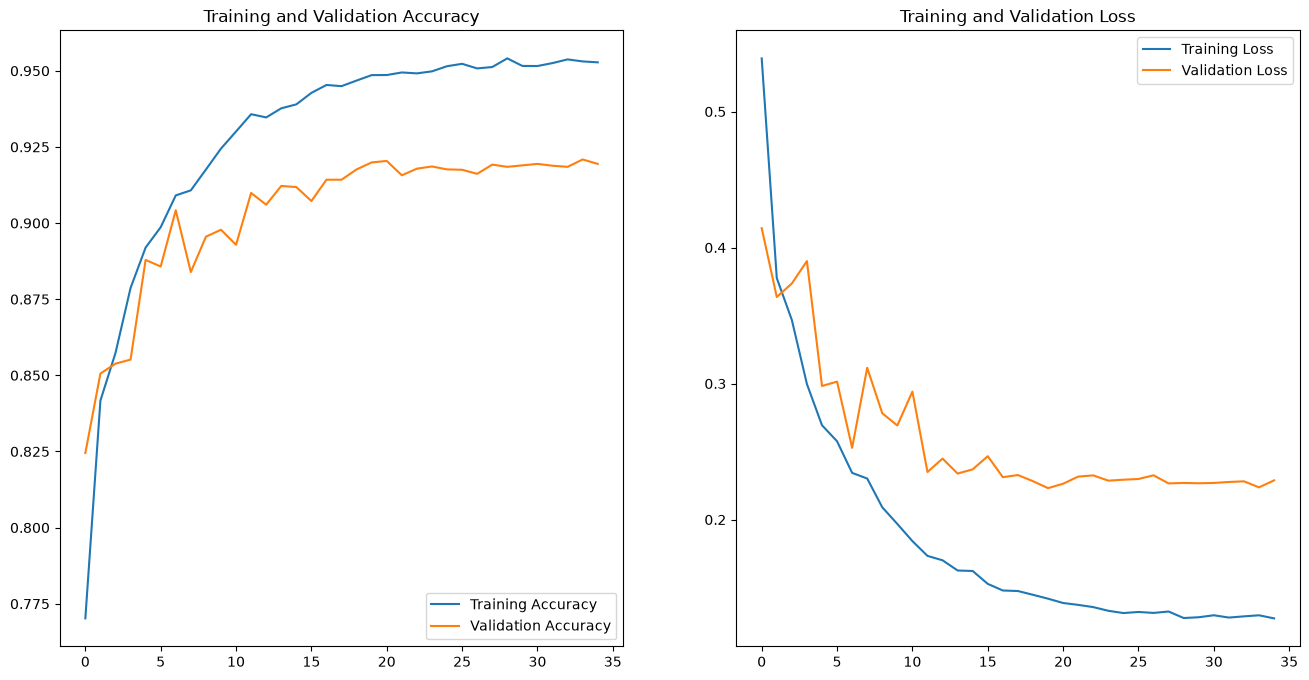

In [11]:
epochs=150             # nombre maximal d'époques : en pratique l'EarlyStopping arrête bien avant
learning_rate = 1e-3   # pas initial d'Adam (valeur par défaut recommandée), réduit ensuite par ReduceLROnPlateau
# Le modèle
complete_model =  Sequential([
    data_augmentation,                                              # transformations aléatoires (entraînement seulement)
    layers.Rescaling(1./255, input_shape=(image_h, image_w, 3)),    # pixels [0, 255] -> [0, 1] : entrées de même échelle que les poids
    # Partie convolutive : filtres 3x3, 'same' garde la taille, LeakyReLU évite les neurones morts.
    # Après chaque MaxPooling la résolution est divisée par 2 et on double le nombre de filtres.
    layers.Conv2D(16, (3, 3), padding='same', activation='leaky_relu'),    # 200x200x16 - motifs simples : contours, grain
    layers.MaxPooling2D(),                                                  # -> 100x100x16
    layers.Conv2D(32, (3, 3), padding='same', activation='leaky_relu'),    # 100x100x32
    layers.MaxPooling2D(),                                                  # -> 50x50x32
    layers.Conv2D(64, (3, 3), padding='same', activation='leaky_relu'),    # 50x50x64 - textures (touches de pinceau…)
    layers.MaxPooling2D(),                                                  # -> 25x25x64
    layers.Conv2D(128, (3, 3), padding='same', activation='leaky_relu'),   # 25x25x128 - motifs abstraits
    # Partie dense : on met tout à plat puis on combine les caractéristiques
    layers.Flatten(),                                                       # 25*25*128 = 80 000 valeurs
    layers.Dense(256, activation='leaky_relu'),                             # 20,5 M de paramètres (99,5 % du réseau)
    layers.Dropout(0.2),  # Couche de dropout pour régularisation : 20 % des neurones éteints au hasard à chaque pas
    layers.Dense(3, activation='softmax')  # 3 classes de sortie : une probabilité par classe, somme = 1
    # (3 sorties : ce code vient du jeu à 3 classes ; avec les 2 dossiers Others/Photo il faudrait len(class_names))
])
# Compilation du modèle
# - optimiseur Adam : descente de gradient avec momentum et pas adaptatif par poids (voir partie 4)
# - perte : entropie croisée « sparse » car les étiquettes sont des entiers (voir partie 3).
#   NB : la dernière couche a déjà un softmax ; Keras le détecte et calcule la perte sur les valeurs
#   d'avant le softmax, le résultat est correct, mais from_logits=False serait l'écriture cohérente.
# - métrique suivie : accuracy (proportion d'images bien classées)
complete_model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                       metrics=['accuracy'])
#Callbacks
# Arrêt anticipé : si la perte de test ne s'améliore plus pendant 15 époques, on arrête
# et on revient aux poids de la meilleure époque (protection contre le sur-apprentissage)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=epochs//10,          # 150 // 10 = 15 époques
    restore_best_weights=True,
    verbose=1
)
# Réduction du pas : dès qu'une époque n'améliore pas la perte de test, le pas est multiplié par 0,75
# (grands pas au début pour avancer vite, petits pas à la fin pour affiner), sans descendre sous 1e-5
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.75,
    patience=epochs//100,         # 150 // 100 = 1 époque
    min_lr=0.00001,
    verbose=1
)
# Résumé du modèle : taille de sortie et nombre de paramètres de chaque couche
complete_model.summary()
# Entrainement du modèle
# fit() parcourt le train_set batch par batch : prédiction, calcul de la perte, rétropropagation du gradient,
# mise à jour des poids par Adam. À la fin de chaque époque, la perte et l'accuracy sont mesurées sur le test_set.
complete_history = complete_model.fit(train_set,
                                      epochs=epochs,
                                      validation_data=(test_set),
                                      callbacks=[reduce_lr, early_stopping])
# Courbes : erreur (loss) et accuracy, sur l'entraînement et sur le test, à chaque époque
acc = complete_history.history['accuracy']
val_acc = complete_history.history['val_accuracy']

loss = complete_history.history['loss']
val_loss = complete_history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 5. Évolution de l'erreur et de l'accuracy (entraînement et test)

**Attention** : la sortie affichée sous la cellule d'entraînement provient de sa dernière exécution, faite sur le **jeu à 3 classes** (`Others` / `Painting` / `Photo`) : à l'époque 20 on lit val_loss 0,2232 et val_accuracy 0,9199, exactement les valeurs du modèle `lucky_model1.1.keras` évalué dans `L1,1.ipynb`. Les courbes ci-dessous sont donc celles du modèle 3 classes. Relancer la cellule d'entraînement sur le jeu `Others` / `Photo` produirait les courbes du modèle 2 classes.

La cellule suivante retrace les quatre courbes demandées (erreur et accuracy, sur les données d'entraînement et de
test) à partir des valeurs affichées par Keras à la fin de chaque époque, recopiées ici pour qu'on puisse les
retrouver sans relancer un entraînement de 30 minutes.

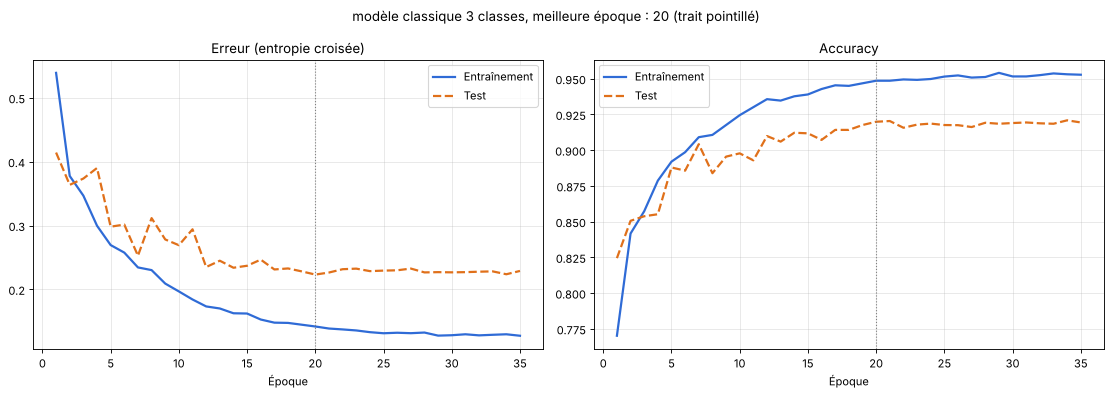

Époque 20 : erreur entraînement 0.142 / test 0.223, accuracy entraînement 94.9% / test 92.0%

In [ ]:
# Historique de l'entraînement du modèle classique 3 classes, recopié depuis les logs Keras (une valeur par époque).
# Équivalent de complete_history.history ; si on ré-entraîne, on peut tracer directement complete_history.history.
historique = {
    "loss":         [0.5391, 0.3776, 0.3468, 0.2997, 0.2694, 0.2576, 0.2344, 0.2302, 0.2091, 0.1968, 0.1842, 0.1733, 0.1701, 0.1626, 0.1622, 0.1528, 0.1479, 0.1475, 0.1447, 0.1419, 0.1387, 0.1373, 0.1357, 0.133, 0.1313, 0.1321, 0.1314, 0.1324, 0.1276, 0.1282, 0.1297, 0.128, 0.1289, 0.1297, 0.1274],
    "val_loss":     [0.4143, 0.3637, 0.3736, 0.3901, 0.2982, 0.3015, 0.2527, 0.3116, 0.2782, 0.2692, 0.2941, 0.235, 0.2449, 0.2339, 0.237, 0.2466, 0.2312, 0.2328, 0.2282, 0.2232, 0.2264, 0.2316, 0.2325, 0.2286, 0.2294, 0.2299, 0.2326, 0.2266, 0.227, 0.2267, 0.227, 0.2277, 0.2282, 0.2237, 0.2289],
    "accuracy":     [0.7702, 0.8417, 0.8573, 0.8787, 0.892, 0.8986, 0.9091, 0.9107, 0.9176, 0.9245, 0.9301, 0.9357, 0.9347, 0.9377, 0.939, 0.9428, 0.9454, 0.945, 0.9468, 0.9486, 0.9486, 0.9495, 0.9492, 0.9498, 0.9515, 0.9523, 0.9508, 0.9512, 0.9541, 0.9516, 0.9516, 0.9525, 0.9537, 0.9531, 0.9528],
    "val_accuracy": [0.8245, 0.8506, 0.8538, 0.8552, 0.8879, 0.8857, 0.9042, 0.8839, 0.8955, 0.8978, 0.8929, 0.9099, 0.906, 0.9122, 0.9118, 0.9072, 0.9142, 0.9142, 0.9176, 0.9199, 0.9204, 0.9157, 0.9179, 0.9186, 0.9176, 0.9175, 0.9162, 0.9192, 0.9185, 0.919, 0.9194, 0.9188, 0.9185, 0.9209, 0.9194],
}

epoques = np.arange(1, len(historique["loss"]) + 1)
meilleure = int(np.argmin(historique["val_loss"])) + 1   # époque restaurée par l'EarlyStopping

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))
for ax, cle, titre in [(ax_loss, "loss", "Erreur (entropie croisée)"), (ax_acc, "accuracy", "Accuracy")]:
    ax.plot(epoques, historique[cle], color="#2f6bd6", lw=2, label="Entraînement")
    ax.plot(epoques, historique["val_" + cle], color="#e0701a", lw=2, ls="--", label="Test")
    ax.axvline(meilleure, color="gray", ls=":", lw=1)
    ax.set_title(titre)
    ax.set_xlabel("Époque")
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(f"modèle classique 3 classes, meilleure époque : {meilleure} (trait pointillé)")
plt.tight_layout()
plt.show()

i = meilleure - 1
print(f"Époque {meilleure} : erreur entraînement {historique['loss'][i]:.3f} / test {historique['val_loss'][i]:.3f}"
      f", accuracy entraînement {historique['accuracy'][i]:.1%} / test {historique['val_accuracy'][i]:.1%}")

## 6. Analyse des résultats : compromis biais / variance

Rappel : le **biais** est l'erreur due à un modèle trop simple ou mal entraîné (**sous-apprentissage** : il se
trompe déjà sur les données d'entraînement) ; la **variance** est l'erreur due à un modèle qui colle trop aux
données d'entraînement (**sur-apprentissage** : bon à l'entraînement, moins bon sur des images nouvelles). On les
lit sur les courbes : niveau de l'erreur d'entraînement → biais ; écart entre entraînement et test → variance.

### Ce que montrent les courbes (modèle 3 classes)

| Époque | Erreur entr. | Erreur test | Accuracy entr. | Accuracy test | Pas d'apprentissage |
|---|---|---|---|---|---|
| 1 | 0,539 | 0,414 | 77,0 % | 82,5 % | 1e-3 |
| 7 | 0,234 | 0,253 | 90,9 % | 90,4 % | 4,2e-4 |
| 12 | 0,173 | 0,235 | 93,6 % | 91,0 % | 1,3e-4 |
| **20 (meilleure)** | **0,142** | **0,223** | **94,9 %** | **92,0 %** | 4,2e-5 |
| 35 (arrêt) | 0,127 | 0,229 | 95,3 % | 91,9 % | 1e-5 |

1. **Époques 1 à 7, apprentissage rapide.** Les deux erreurs chutent ensemble. Au début l'erreur de test est même
   plus basse que celle d'entraînement : c'est normal, l'erreur d'entraînement est une moyenne sur toute l'époque
   (alors que le réseau progresse pendant l'époque) et elle est mesurée avec le dropout et l'augmentation actifs,
   ce qui rend la tâche plus difficile qu'au test.
2. **Époques 8 à 20, les courbes se séparent.** L'erreur d'entraînement continue de baisser régulièrement
   (0,23 → 0,14) mais l'erreur de test baisse lentement en oscillant (0,31 → 0,22). Les oscillations viennent du pas
   encore grand ; `ReduceLROnPlateau` le réduit presque à chaque époque.
3. **Après l'époque 20, plateau.** L'erreur de test ne bouge plus (≈ 0,225-0,233) pendant que l'erreur
   d'entraînement descend encore un peu : le réseau commence à apprendre des détails propres aux images
   d'entraînement. Le pas atteint son minimum (1e-5) à l'époque 26, l'apprentissage est figé ; l'early stopping
   arrête à l'époque 35 et restaure les poids de l'époque 20.

### Diagnostic

* **Variance (sur-apprentissage) : modérée.** À la meilleure époque, l'écart d'accuracy entraînement / test est de
  **3 points** (94,9 % contre 92,0 %) et l'erreur de test est 1,6 fois l'erreur d'entraînement ; ensuite l'écart se
  creuse alors que le test stagne. C'est le début d'un sur-apprentissage, contenu par le dropout, l'augmentation,
  la baisse du pas et l'early stopping (sans eux, avec 20,5 millions de paramètres pour 33 000 images, l'écart
  serait bien plus grand).
* **Biais (sous-apprentissage) : présent aussi.** Même sur l'entraînement, le réseau plafonne vers 95 % : il ne
  parvient pas à classer parfaitement les images qu'il a déjà vues. Causes probables : partie convolutive peu
  profonde (4 blocs), résolution de 200×200 qui efface les textures fines qui trahissent une peinture ou une photo,
  et images réellement ambiguës (peintures hyperréalistes, photos retouchées, dessins numériques) voire mal
  étiquetées.
* **Conclusion** : le modèle est dans une zone raisonnable du compromis : l'early stopping l'a arrêté avant que la
  variance ne domine, mais il reste du biais **et** de la variance à gagner. Le déséquilibre du réseau (un
  convolutif léger suivi d'une couche dense énorme) est le point faible : beaucoup de paramètres là où ils servent
  à mémoriser, peu là où ils servent à extraire des caractéristiques.

### Limites de la mesure

* Le `test_set` sert aussi à choisir l'époque d'arrêt et à piloter le pas : le score de 92,0 % est donc
  **légèrement optimiste**. Il faudrait un troisième ensemble jamais vu (par exemple 70 / 15 / 15).
* L'accuracy globale masque les classes : il faut aussi regarder la matrice de confusion (fonction `afficher_matrice_confusion`), qui montre quelles classes se mélangent.
* Sur les photos de test, la prédiction varie selon la manière de redimensionner l'image : `load_img(target_size=…)`
  (plus proche voisin) ne donne pas les mêmes probabilités que l'interpolation bilinéaire utilisée à l'entraînement.
  La dernière cellule du notebook `L1,1` utilise `tf.image.resize` (bilinéaire) pour être cohérente.

### Outil d'analyse : la matrice de confusion

L'accuracy est un seul chiffre ; la matrice de confusion montre **quelles classes sont confondues entre elles**.

I0000 00:00:1790924233.675111   58873 cuda_dnn.cc:461] Loaded cuDNN version 92600


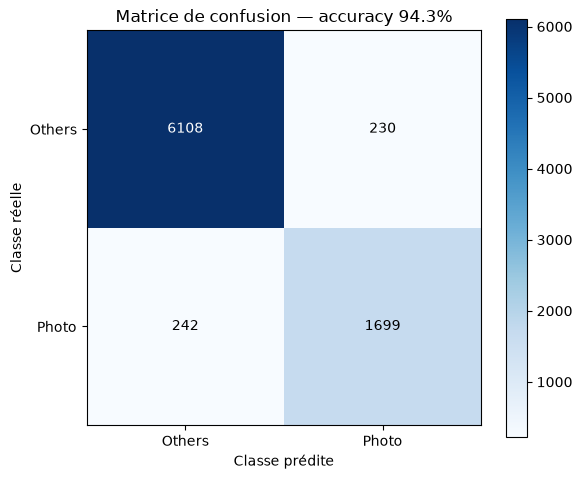

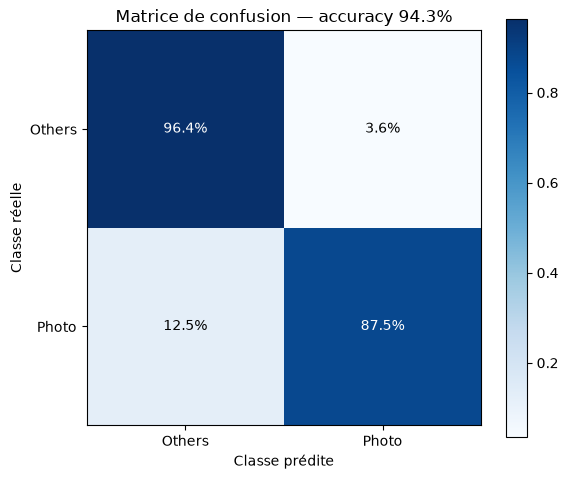

In [15]:
def afficher_matrice_confusion(model, dataset, class_names, normaliser=False):
    """Matrice de confusion : ligne = vraie classe, colonne = classe prédite.

    La diagonale contient les images bien classées ; les autres cases montrent quelles classes se mélangent.
    Avec normaliser=True chaque ligne est en pourcentage : la diagonale donne le rappel de chaque classe.
    """
    y_true, y_pred = [], []
    # On prédit batch par batch dans la MÊME boucle que les labels : un tf.data.Dataset peut être
    # remélangé à chaque parcours, deux boucles séparées risqueraient de ne pas aligner images et étiquettes
    for images, labels in dataset:
        logits = model.predict_on_batch(images)
        y_true.append(labels.numpy())
        y_pred.append(np.argmax(logits, axis=1))      # classe prédite = sortie la plus forte
    y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()
    if normaliser:
        cm = cm / cm.sum(axis=1, keepdims=True)   # proportions par classe réelle

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)), labels=class_names)
    ax.set_yticks(range(len(class_names)), labels=class_names)
    ax.set_xlabel("Classe prédite")
    ax.set_ylabel("Classe réelle")
    ax.set_title(f"Matrice de confusion - accuracy {np.mean(y_true == y_pred):.1%}")

    # Valeur écrite dans chaque case (texte blanc sur les cases foncées)
    seuil = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            texte = f"{cm[i, j]:.1%}" if normaliser else f"{cm[i, j]:d}"
            ax.text(j, i, texte, ha="center", va="center",
                    color="white" if cm[i, j] > seuil else "black")

    plt.tight_layout()
    plt.show()
    return cm

cm = afficher_matrice_confusion(complete_model, test_set, class_names)
cm_norm = afficher_matrice_confusion(complete_model, test_set, class_names, normaliser=True)

In [ ]:
# Sauvegarde du modèle entraîné (architecture + poids + état d'Adam) au format .keras
model_path = pathlib.Path("../models")
model_path.mkdir(exist_ok=True, parents=True)

# complete_model.save(model_path / "lucky_model1.1.keras")
# print(f"Modèle sauvegardé dans : {model_path.resolve()}")

In [16]:
# Rechargement du modèle sauvegardé et évaluation sur le test_set : [perte, accuracy]
# MODÈLE RETENU de ce notebook : c'est lui qui est testable sur le site (Test_website/modeles/model_photo_autre)
# lucky_model2 : version 2 classes (3 blocs convolutifs, Dense(128), 2 sorties logits), 94,3 % d'accuracy
model_file_path = model_path / "lucky_model2.keras"
complete_model = keras.models.load_model(model_file_path)

complete_model.summary()
complete_model.evaluate(test_set)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    20,480,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,511,912 (234.65 MB)

 Trainable params: 20,503,970 (78.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 41,007,942 (156.43 MB)

65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.9430 - loss: 0.1613


[0.1612982302904129, 0.9429882764816284]

### Modèle retenu

Le modèle chargé ci-dessus, **`lucky_model2.keras`**, est le **modèle retenu** de ce notebook : c'est lui qui est
exporté sur le site (`Test_website/modeles/model_photo_autre`). Perte 0,161 et accuracy **94,3 %** sur le test.

### Le modèle 2 classes chargé (`lucky_model2.keras`)

La cellule précédente évalue le modèle sauvegardé `lucky_model2.keras` : **94,3 % d'accuracy** sur le jeu de test
(perte 0,161). Son architecture est un peu plus légère que celle du code ci-dessus : 3 blocs convolutifs
(16, 32, 64 filtres, sans pooling après le troisième), `Flatten` (160 000 valeurs), `Dense(128)` + Dropout, et
2 sorties linéaires (logits), soit 20,5 millions de paramètres, là encore presque tous dans la couche dense.

La matrice de confusion (cellule plus haut, calculée avec ce modèle chargé) montre l'effet du **déséquilibre des classes** : le jeu de test contient 6 338 images
`Others` pour 1 941 `Photo` (77 % / 23 %). Un modèle qui répondrait toujours `Others` aurait déjà 77 %
d'accuracy, d'où l'intérêt de regarder chaque classe :

| | Rappel (images bien retrouvées) | Précision (prédictions justes) |
|---|---|---|
| `Others` | 96,4 % (6 108 / 6 338) | 96,2 % (6 108 / 6 350) |
| `Photo` | **87,5 %** (1 699 / 1 941) | 88,1 % (1 699 / 1 929) |

Le modèle rate une photo sur huit : la classe minoritaire est la moins bien apprise (biais envers la classe
majoritaire). Pistes : pondérer la perte (`class_weight`) ou rééquilibrer le jeu de données (voir partie 7).

### Test sur nos propres images

Douze images choisies à la main (photos, peintures célèbres, dessin, image de synthèse), jamais vues pendant l'entraînement, pour juger le modèle sur des cas concrets.

Jauconde.jpg                 → Others    | Others 100.0%  Photo   0.0%
Terre.jpg                    → Others    | Others 100.0%  Photo   0.0%
etrange.jpg                  → Photo     | Others   1.8%  Photo  98.2%
homme devant fenetre.jpg     → Photo     | Others   0.4%  Photo  99.6%
nuit sous les étoiles.jpg    → Others    | Others  99.9%  Photo   0.1%
peinture wiki.jpg            → Others    | Others  73.0%  Photo  27.0%
photo1.jpg                   → Others    | Others  83.4%  Photo  16.6%
photo2.jpg                   → Photo     | Others  13.8%  Photo  86.2%
photo3.jpg                   → Photo     | Others  10.4%  Photo  89.6%
photo4.jpg                   → Others    | Others 100.0%  Photo   0.0%
tropius.jpg                  → Others    | Others  99.9%  Photo   0.1%
voie_lactée.jpg              → Others    | Others  64.0%  Photo  36.0%


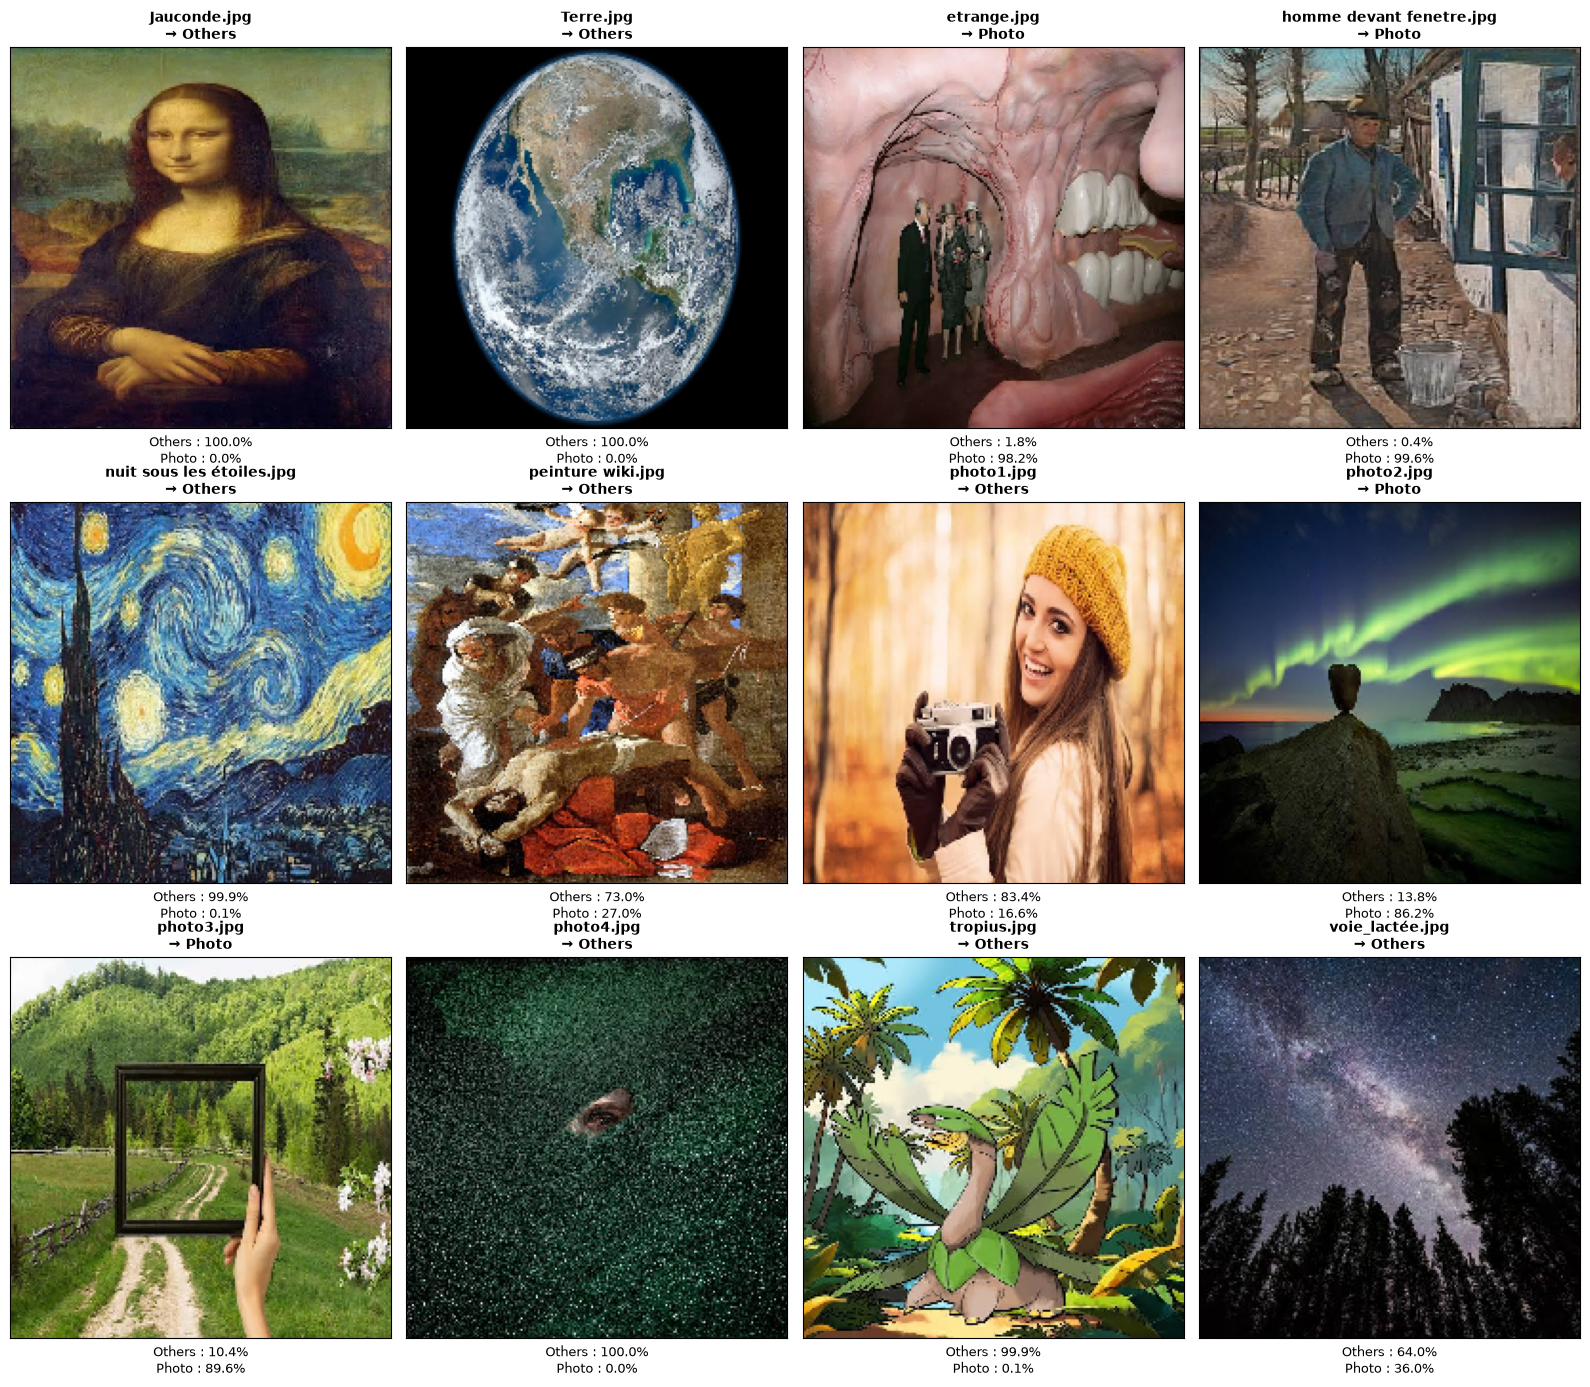

In [18]:
# Test du modèle sur nos propres images (dossier Test_photos), jamais vues pendant l'entraînement.
# Remarque : load_img(target_size=...) redimensionne au plus proche voisin, alors que l'entraînement utilise
# une interpolation bilinéaire ; les probabilités peuvent donc légèrement différer de celles du site web
# (la cellule de la cascade, dans L1,1, utilise tf.image.resize pour être cohérente avec l'entraînement).
test_photos_dir = pathlib.Path("../Test_photos")
extensions_images = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
nb_colonnes = 4

# Le modèle doit avoir autant de sorties que de classes (3 : Others, Painting, Photo)
nb_sorties = complete_model.output_shape[-1]
if nb_sorties != len(class_names):
    raise ValueError(
        f"Le modèle a {nb_sorties} sorties mais il y a {len(class_names)} classes {class_names}. "
        "Vérifie que complete_model est bien le modèle entraîné sur ce dataset."
    )

# Si la dernière couche a déjà un softmax, ses sorties sont des probabilités : on ne le réapplique pas
sortie_softmax = getattr(complete_model.layers[-1].activation, "__name__", "") == "softmax"

if not test_photos_dir.is_dir():
    raise FileNotFoundError(f"Dossier introuvable : {test_photos_dir.resolve()}")

image_paths = sorted(
    p for p in test_photos_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in extensions_images
)

if not image_paths:
    print(f"Aucune image trouvée dans {test_photos_dir.resolve()}")
else:
    images = [keras.utils.load_img(p, target_size=(image_h, image_w), color_mode="rgb") for p in image_paths]
    batch = np.stack([keras.utils.img_to_array(img) for img in images])

    # Une seule prédiction pour toutes les images (plus rapide et moins de mémoire qu'une par image)
    sorties = complete_model.predict(batch, verbose=0)
    probabilities = sorties if sortie_softmax else tf.nn.softmax(sorties, axis=1).numpy()

    nb_lignes = int(np.ceil(len(images) / nb_colonnes))
    fig = plt.figure(figsize=(4 * nb_colonnes, 4.6 * nb_lignes))
    for i, (image_path, image, probas) in enumerate(zip(image_paths, images, probabilities)):
        predicted_index = int(np.argmax(probas))
        detail = "\n".join(f"{name} : {p:.1%}" for name, p in zip(class_names, probas))

        ax = fig.add_subplot(nb_lignes, nb_colonnes, i + 1)
        ax.imshow(image)
        ax.set_title(f"{image_path.name}\n→ {class_names[predicted_index]}", fontsize=10, fontweight="bold")
        ax.set_xlabel(detail, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

        print(f"{image_path.name:<28} → {class_names[predicted_index]:<9} | "
              + "  ".join(f"{name} {p:6.1%}" for name, p in zip(class_names, probas)))

    plt.tight_layout()
    plt.show()
    plt.close(fig)

## 7. Méthodes pour améliorer le compromis biais / variance

| Méthode | Réduit surtout | Déjà utilisé ? | Ce qu'on ferait |
|---|---|---|---|
| **Early stopping** | la variance | oui (`patience=15`, meilleurs poids restaurés) | garder ; avec `patience` 8-10 on gagnerait du temps sans perte, puisque le pas est déjà au minimum dès l'époque 26 |
| **Dropout** | la variance | oui, 0,2 après la couche dense | monter à 0,4-0,5 sur la couche dense, ajouter `SpatialDropout2D(0.1)` après les convolutions |
| **Régularisation L2** (*weight decay*) | la variance | non | `kernel_regularizer=keras.regularizers.l2(1e-4)` sur les couches `Dense`, ou l'optimiseur `AdamW` : pénalise les poids trop grands, donc les modèles trop « collés » aux données |
| **Augmentation de données** | la variance | oui (miroir, rotation, zoom) | ajouter `RandomTranslation`, `RandomCrop` ; éviter de trop toucher aux couleurs, qui sont un indice de la classe |
| **Moins de paramètres** : `GlobalAveragePooling2D` à la place de `Flatten` | la variance | non | la couche `Dense(256)` passerait de 20,5 M à 33 000 paramètres (128·256 + 256) : c'est le changement le plus efficace pour ce réseau |
| **Batch Normalization** | biais et variance | non | après chaque convolution : entraînement plus stable, possibilité d'un pas plus grand, léger effet régularisant |
| **Plus de données / rééquilibrage** | la variance (et le biais sur la classe rare) | non | ajouter des images, `class_weight` dans `fit`, nettoyer les étiquettes douteuses |
| **Réseau plus profond / plus de filtres** | le biais | partiellement (le modèle P2P passe en 400×400) | 5-6 blocs convolutifs, 2 convolutions par bloc |
| **Résolution plus grande** | le biais | oui pour le modèle P2P (400×400) | garde les textures fines (grain photo, touches de pinceau) |
| **Transfer learning** | biais et variance | non | partir d'un réseau pré-entraîné sur ImageNet (`MobileNetV3`, `EfficientNetB0`), geler ses couches et n'entraîner que la tête : de bonnes caractéristiques visuelles dès le départ avec peu de paramètres à apprendre |
| **Réglage du pas** | le biais | oui (`ReduceLROnPlateau`) | `patience=2` ou 3 au lieu de 1 : aujourd'hui le pas est divisé dès la moindre oscillation et atteint son minimum trop tôt, ce qui fige l'apprentissage |
| **Vrai jeu de test séparé**, validation croisée | (mesure) | non | découper 70 / 15 / 15 pour mesurer honnêtement la généralisation |

Règle de lecture : si l'erreur d'**entraînement** est trop haute → augmenter la capacité (réseau plus grand,
résolution, entraînement plus long, moins de régularisation). Si l'**écart** entraînement / test est trop grand →
régulariser (dropout, L2, augmentation, moins de paramètres, plus de données, early stopping).

Exemple de tête de réseau plus légère (non entraînée ici) :

```python
layers.Conv2D(128, (3, 3), padding='same', activation='leaky_relu'),
layers.GlobalAveragePooling2D(),                                      # 128 valeurs au lieu de 80 000
layers.Dense(256, activation='leaky_relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
layers.Dropout(0.4),
layers.Dense(len(class_names), activation='softmax'),
```

## Conclusion

* **Modèle retenu : `lucky_model2.keras`**, testable sur le site (modèle `model_photo_autre`).
* Le réseau convolutif (4 blocs Conv/MaxPooling, Dense 256, Dropout, softmax) est entraîné avec une **entropie croisée** et l'optimiseur **Adam** (pas 1e-3 réduit sur plateau, early stopping).
* Il atteint **94,3 %** sur le test, mais seulement 87,5 % de rappel sur les photos à cause du déséquilibre des classes.
* Les courbes montrent un **léger sur-apprentissage** contenu par la régularisation et un **biais résiduel** (≈ 5 % d'erreur même à l'entraînement).
* Suite : `L1,1.ipynb` sépare les peintures (3 classes) ; son modèle retenu est `lucky_model1.1.keras`.